In [4]:
import numpy as np
import gstools as gs
import matplotlib.pyplot as plt
from scipy.ndimage import convolve



x=y=z = range(100)
model_1 = gs.Gaussian(dim=3, var=1, len_scale=[2, 2, 2], angles=[0, 0, 0])

model_2 = gs.Gaussian(dim=3, var=1, len_scale=[5, 5, 5], angles=[0, 0, 0])

model_3 = gs.Gaussian(dim=3, var=1, len_scale=[10, 10, 10], angles=[0, 0, 0])

srf_1 = gs.SRF(model_1)
srf_2 = gs.SRF(model_2)
srf_3 = gs.SRF(model_3)

srf_1((x,y,z), mesh_type='structured' , seed=0)
srf_2((x,y,z), mesh_type='structured' , seed=1)
srf_3((x,y,z), mesh_type='structured' , seed=2)

mesh_1 = srf_1.to_pyvista() 
mesh_2 = srf_2.to_pyvista() 
mesh_3 = srf_3.to_pyvista() 

mesh_1.contour(isosurfaces=50).plot()
mesh_2.contour(isosurfaces=50).plot()
mesh_3.contour(isosurfaces=50).plot()


Widget(value='<iframe src="http://localhost:55689/index.html?ui=P_0x18a3e9ac550_2&reconnect=auto" class="pyvis…

Widget(value='<iframe src="http://localhost:55689/index.html?ui=P_0x18a3e9ae0d0_3&reconnect=auto" class="pyvis…

Widget(value='<iframe src="http://localhost:55689/index.html?ui=P_0x18a3e9ae990_4&reconnect=auto" class="pyvis…

In [5]:
import numpy as np
import gstools as gs
import matplotlib.pyplot as plt
from scipy.ndimage import convolve



x=y = range(100)
model_1_2d = gs.Gaussian(dim=2, var=1, len_scale=[2, 2], angles=[0, 0])

model_2_2d = gs.Gaussian(dim=2, var=1, len_scale=[1, 5], angles=[np.pi/4, np.pi/4])



srf_1_2d = gs.SRF(model_1_2d)
srf_2_2d = gs.SRF(model_2_2d)


srf_1_2d((x,y), mesh_type='structured' , seed=0)
srf_2_2d((x,y), mesh_type='structured' , seed=1)


mesh_1_2d = srf_1_2d.to_pyvista() 
mesh_2_2d = srf_2_2d.to_pyvista() 
 

mesh_1_2d.contour(isosurfaces=50).plot()
mesh_2_2d.contour(isosurfaces=50).plot()

field_1_2d = srf_1_2d.field
field_2_2d = srf_2_2d.field




Widget(value='<iframe src="http://localhost:55689/index.html?ui=P_0x18a3e9af890_5&reconnect=auto" class="pyvis…

Widget(value='<iframe src="http://localhost:55689/index.html?ui=P_0x18a3e9afed0_6&reconnect=auto" class="pyvis…

Rock type 0: 48.8%
Rock type 1: 36.9%
Rock type 2: 14.3%


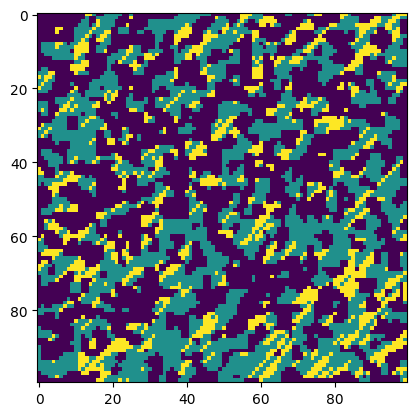

In [6]:
import numpy as np

lithotype_map = np.zeros((100, 100))

cut_1 = 0.0
cut_2 = 0.5

lithotype_map[(field_1_2d >= cut_1) & (field_2_2d < cut_2)] = 1

lithotype_map[(field_1_2d >= cut_1) & (field_2_2d >= cut_2)] = 2

plt.imshow(lithotype_map, cmap='viridis')


total = lithotype_map.size
print(f"Rock type 0: {(lithotype_map == 0).sum() / total * 100:.1f}%")
print(f"Rock type 1: {(lithotype_map == 1).sum() / total * 100:.1f}%")
print(f"Rock type 2: {(lithotype_map == 2).sum() / total * 100:.1f}%")


C:\Users\barbe\AppData\Local\Temp\ipykernel_11092\2678464764.py:8: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(neighbours, minlength=3)


Generation 10:
  Rock type 0: 92.4%
  Rock type 1: 7.0%
  Rock type 2: 0.6%
Generation 100:
  Rock type 0: 98.5%
  Rock type 1: 1.1%
  Rock type 2: 0.4%
Generation 1000:
  Rock type 0: 98.5%
  Rock type 1: 1.1%
  Rock type 2: 0.4%


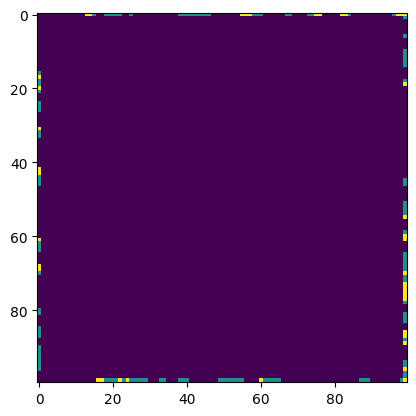

In [7]:
checkpoints = [10, 100, 1000]

for generation in range(1000):
    new_grid = lithotype_map.copy()
    for i in range(1, lithotype_map.shape[0]-1):
        for j in range(1, lithotype_map.shape[1]-1):
            neighbours = [lithotype_map[i-1, j], lithotype_map[i+1, j], lithotype_map[i, j-1], lithotype_map[i, j+1]]
            counts = np.bincount(neighbours, minlength=3)
            if counts.max() > 1:
                new_grid[i, j] = counts.argmax()
    lithotype_map = new_grid
    
    if generation+1 in checkpoints:
        total = lithotype_map.size
        print(f"Generation {generation+1}:")
        print(f"  Rock type 0: {(lithotype_map == 0).sum() / total * 100:.1f}%")
        print(f"  Rock type 1: {(lithotype_map == 1).sum() / total * 100:.1f}%")
        print(f"  Rock type 2: {(lithotype_map == 2).sum() / total * 100:.1f}%")

plt.imshow(lithotype_map, cmap='viridis')
plt.show()

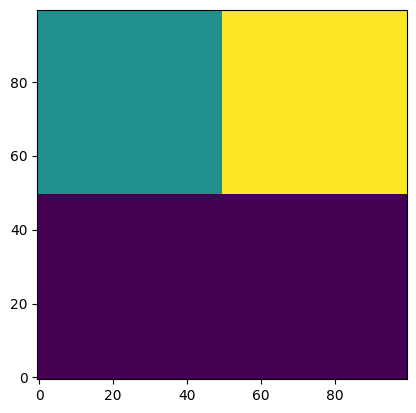

In [8]:
import numpy as np
import matplotlib.pyplot as plt


rule_diagram = np.zeros((100, 100))

rule_diagram[50:100, 0:50] = 1

rule_diagram[50:100, 50:100] = 2

plt.imshow(rule_diagram, origin='lower', cmap='viridis')
plt.show()

Project: Virtual Prototyping of a Deep Geothermal Aquifer (gemini special)
Background & Objective:
To maximize energy extraction and prevent wasted drilling resources, we need to mathematically model the fluid dynamics of a subsurface geothermal reservoir. Before we can run dynamic fluid simulations, we must first construct the static geological environment. This notebook uses Plurigaussian simulation to generate a highly accurate 2D cross-section of the subterranean rock layers based on limited core sample data.

Geological Targets:
Physical testing indicates the reservoir is composed of three distinct lithotypes. Our mathematical model must strictly enforce these real-world volumetric proportions:

Phase 0 (Impermeable Granite Matrix): 65%. This dense rock forms the primary boundary structure and prevents fluid escape.

Phase 1 (Porous Sandstone Channels): 25%. The open, sponge-like network that serves as the main conduit for heated fluids.

Phase 2 (Dense Quartz Inclusions): 10%. Solid, crystalline blocks scattered within the channels that force the fluid to divert and branch.

In [16]:
import numpy as np
import gstools as gs
import pyvista as pv
import matplotlib.pyplot as plt
from scipy.stats import norm

granite_percent = 0.65
sandstone_percent = 0.25
quartz_percent = 0.10

cut_1 = norm.ppf(granite_percent)
cut_2 = norm.ppf(sandstone_percent/(quartz_percent + sandstone_percent))

grid = range(100)

model_a = gs.Gaussian(dim=3, var=1.0, len_scale=[80, 20, 10])
srf_a = gs.SRF(model_a, seed=1)
field_a = srf_a.structured([grid, grid, grid])

model_b = gs.Gaussian(dim=3, var=1.0, len_scale=[60, 60, 30])
srf_b = gs.SRF(model_b, seed=2)
field_b = srf_b.structured([grid, grid, grid])

reservoir_map = np.zeros((len(grid), len(grid), len(grid)), dtype=np.int32)
reservoir_map[(field_a >= cut_1) & (field_b < cut_2)] = 1
reservoir_map[(field_a >= cut_1) & (field_b >= cut_2)] = 2

print("Original:", (reservoir_map == 0).sum(), (reservoir_map == 1).sum(), (reservoir_map == 2).sum())
original_map = reservoir_map.copy()

Original: 633673 311537 54790


In [17]:
for generation in range(100):
    new_grid = reservoir_map.copy()
    for i in range(1, reservoir_map.shape[0]-1):
        for j in range(1, reservoir_map.shape[1]-1):
            for k in range(1, reservoir_map.shape[2]-1):
                neighbours = [
                    reservoir_map[i-1, j, k],
                    reservoir_map[i+1, j, k],
                    reservoir_map[i, j-1, k],
                    reservoir_map[i, j+1, k],
                    reservoir_map[i, j, k-1],
                    reservoir_map[i, j, k+1]]
                counts = np.bincount(neighbours, minlength=3)
                if counts.max() > 1:
                    new_grid[i, j, k] = counts.argmax()
    reservoir_map = new_grid
    

print("After:", (reservoir_map == 0).sum(), (reservoir_map == 1).sum(), (reservoir_map == 2).sum())


After: 793309 193602 13089


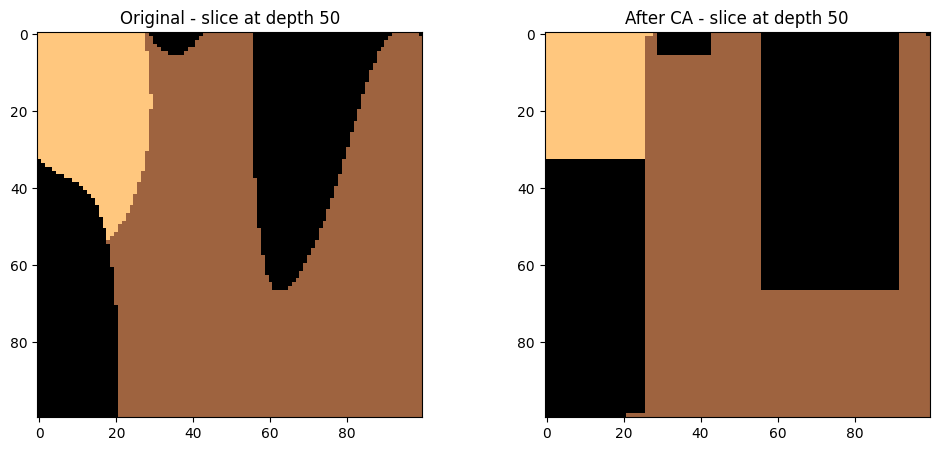

Widget(value='<iframe src="http://localhost:55689/index.html?ui=P_0x18a5b012850_21&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:55689/index.html?ui=P_0x18a5b013110_22&reconnect=auto" class="pyvi…

In [19]:
depth_slice = 50

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original_map[:, :, depth_slice], cmap='copper')
axes[0].set_title(f'Original - slice at depth {depth_slice}')
axes[1].imshow(reservoir_map[:, :, depth_slice], cmap='copper')
axes[1].set_title(f'After CA - slice at depth {depth_slice}')
plt.show()

# pre ca
grid_pv = pv.ImageData(dimensions=(len(grid)+1, len(grid)+1, len(grid)+1))
grid_pv.cell_data['lithotype'] = original_map.flatten(order='F')
plotter = pv.Plotter()
plotter.add_text('Original')
plotter.add_mesh(grid_pv, scalars='lithotype', cmap='copper', smooth_shading=True)
plotter.show()

# post ca 
grid_pv = pv.ImageData(dimensions=(len(grid)+1, len(grid)+1, len(grid)+1))
grid_pv.cell_data['lithotype'] = reservoir_map.flatten(order='F')
plotter = pv.Plotter()
plotter.add_text('After CA')
plotter.add_mesh(grid_pv, scalars='lithotype', cmap='copper', smooth_shading=True)
plotter.show()